 ---

 $$\dfrac{\partial \omega}{\partial t} + u \dfrac{\partial \omega}{\partial x} + v \dfrac{\partial \omega}{\partial y} = \dfrac{1}{Re} \left( \dfrac{\partial^2 \omega}{\partial x^2} + \dfrac{\partial^2 \omega}{\partial y^2} \right)$$

---

$$\dfrac{\partial^2 \psi}{\partial x^2} + \dfrac{\partial^2 \psi}{\partial y^2} = - \omega$$

---

$$u = \dfrac{\partial \psi}{\partial y}, \hspace{1cm} v = -\dfrac{\partial \psi}{\partial x}$$

---

$$w = \dfrac{\partial v}{\partial x} - \dfrac{\partial u}{\partial y}$$

---


# Bibliotecas

In [ ]:
#------------------- Bibliotecas utilizadas --------------------------
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from IPython.display import display, Math, Latex

import time
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

from devito import Grid, Function, TimeFunction, Operator, Eq, solve, configuration
from devito import  sqrt, ConditionalDimension, ConditionalDimension
from devito.finite_differences import Derivative
from devito.logger import warning
from examples.cfd import plot_field, init_hat
from devito import VectorTimeFunction, grad, laplace

from matplotlib import pyplot as plt
from matplotlib import cm
from sympy import nsimplify, pprint
from os import name

# Cavidade

## Definições

In [ ]:
def vorticity_operator(omega, psi, u, v, Re, grid, nx = None):
    grid = grid
    t = grid.stepping_dim
    x, y = grid.dimensions
    vel = 1
    ny = nx

    k_b = 0    # velocidade da parede bottom
    k_t = vel  # velocidade da parede top
    k_l = 0    # velocidade da parede left
    k_r = 0    # velocidade da parede right

    # Equação de vorticidade
    pde_omega = Eq(omega.dt + u * omega.dxc + v * omega.dyc - (1/Re) * (omega.dx2 + omega.dy2))

    # Equação de Poisson
    pde_psi = Eq(psi.dx2 + psi.dy2 + omega)

    # Velocidades
    eq_u = Eq(u, psi.dyc)
    eq_v = Eq(v, -psi.dxc)

    # -=-=--=-=--=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
    stencil_omega = solve(pde_omega, omega.forward)
    stencil_psi = solve(pde_psi, psi)
    stencil_u = solve(eq_u, u)
    stencil_v = solve(eq_v, v)

    update_omega = Eq(omega.forward, stencil_omega, subdomain=grid.interior)
    update_psi = Eq(psi.forward, stencil_psi, subdomain=grid.interior)
    update_u = Eq(u.forward, stencil_u, subdomain = grid.interior)
    update_v = Eq(v.forward, stencil_v, subdomain = grid.interior)

    # Boundary Conditions
    # Vorticidade nas paredes
    bc_omega = [Eq(omega[t+1, 0, y], -(8*psi[t+1, 1, y] - 7*psi[t+1,0,y] - psi[t+1,2,y] + 6*x.spacing* k_l)/(2* x.spacing**2))]   # left
    bc_omega += [Eq(omega[t+1, nx-1, y], -(8*psi[t+1, nx-2, y] - 7*psi[t+1,nx-1,y] - psi[t+1,nx-3,y] + 6*x.spacing* k_r)/(2* x.spacing**2))]  # right
    bc_omega += [Eq(omega[t+1, x, 0], -(8*psi[t+1, x, 1] - 7*psi[t+1,x,0] - psi[t+1,x,2] + 6*y.spacing* k_b)/(2* y.spacing**2) )]   # bottom
    bc_omega += [Eq(omega[t+1, x, ny-1], -(8*psi[t+1, x, ny-2] - 7*psi[t+1,x,ny-1] - psi[t+1,x,ny-3] + 6*y.spacing* k_t)/(2* y.spacing**2))]  # top

    # Streamfunction nas paredes
    bc_psi = [Eq(psi[t+1, 0, y], 0)]   # left
    bc_psi += [Eq(psi[t+1, nx-1, y], 0)]  # right
    bc_psi += [Eq(psi[t+1, x, 0], 0)]   # bottom
    bc_psi += [Eq(psi[t+1,x,ny-1], 0)]    # top

    # Velocidade nas paredes
    bc_u = [Eq(u[t+1, 0, y], 0)]   # left
    bc_u += [Eq(u[t+1, nx-1, y], 0)]  # right
    bc_u += [Eq(u[t+1, x, 0], 0)]   # bottom
    bc_u += [Eq(u[t+1, x, ny-1], vel)]  # top

    bc_v = [Eq(v[t+1, 0, y], 0)]   # left
    bc_v += [Eq(v[t+1, nx-1, y], 0)]  # right
    bc_v += [Eq(v[t+1, x, 0], 0)]   # bottom
    bc_v += [Eq(v[t+1, x, ny-1], 0)]  # top

    bc = bc_omega + bc_psi + bc_u + bc_v

    # Operador principal
    op = Operator([update_omega, update_psi, update_u, update_v] + bc)

    return op

In [ ]:
def run_simulation(nx, Re, alpha, Tmax):
  Lx = 1
  Ly = 1
  ny = nx
  dx = Lx / (nx - 1)
  dy = Ly / (ny - 1)

  dt_visc =  (Re/2) * 1/(1/dx**2 + 1/dy**2)
  dt_cfl = min(dx,dy)
  dt =  alpha * min(dt_visc, dt_cfl)

  nt = int(Tmax/dt)

  x_np = np.linspace(0, Lx, nx)
  y_np = np.linspace(0, Ly, ny)
  X,Y = np.meshgrid(x_np,y_np)
  grid = Grid(shape=(nx, ny), extent=(Lx, Ly))

  time_dim = grid.time_dim

  w = TimeFunction(name='omega', grid=grid, space_order=2)
  psi = TimeFunction(name='psi', grid=grid, space_order=2)
  u = TimeFunction(name='u', grid=grid, space_order=2)
  v = TimeFunction(name='v', grid=grid, space_order=2)

  # Initial Conditions
  w.data[0] = np.ones((nx, ny))
  psi.data[0] = np.zeros((nx, ny))
  u.data[0] = np.zeros((nx, ny))
  v.data[0] = np.zeros((nx, ny))

  # Compile the operator
  configuration['log-level'] = 'ERROR'
  op = vorticity_operator(w, psi, u, v, Re, grid, nx)
  op.apply(omega=w, psi=psi, u=u, v=v, dt=dt, time_M=nt-2)

  n = 8
  fig = plt.figure(figsize=(7, 5), dpi=100)
  # plots the field as a contour
  plt.contourf(X, Y, psi.data[0].T, levels=900, alpha=0.7, cmap=plt.cm.rainbow)
  plt.colorbar()
  # plots the field outlines
  plt.contour(X, Y, psi.data[0].T, levels= 10, cmap=cm.viridis)
  plt.quiver(X[::n, ::n], Y[::n, ::n], u.data[0,::n, ::n].T, v.data[0,::n, ::n].T)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()

  fig, ax = plt.subplots(figsize=(4, 4), dpi=100)

  # Contornos apenas com linhas, sem preenchimento
  contours = ax.contour(X, Y, psi.data[0].T, levels=20, colors='k', linewidths=0.8)
  # Opcional: adicionar rótulos às linhas de contorno
  ax.clabel(contours, inline=True, fontsize=8)

  ax.set_xlabel('x')
  ax.set_ylabel('y')
  plt.tight_layout()
  plt.show()

  fig = plt.figure(figsize=(4,4), dpi=100)   # formato mais vertical
  plt.contour(X, Y, psi.data[0].T,
            levels=320,          # ajuste para mais ou menos curvas
            colors='k',         # linhas pretas
            linewidths=1)       # espessura das linhas
  plt.xlabel('X')
  plt.ylabel('Y')
  plt.tight_layout()
  plt.show()

  return w, psi, u, v

## Solução Numérica

0.000390625


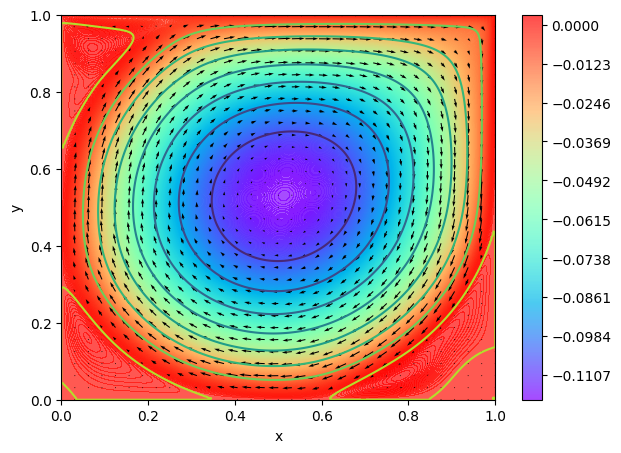

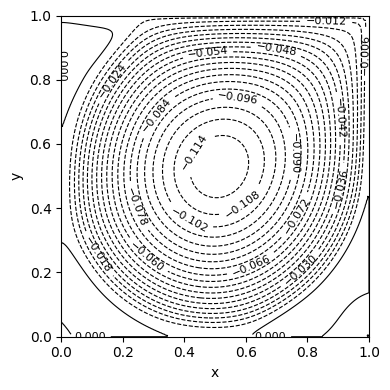

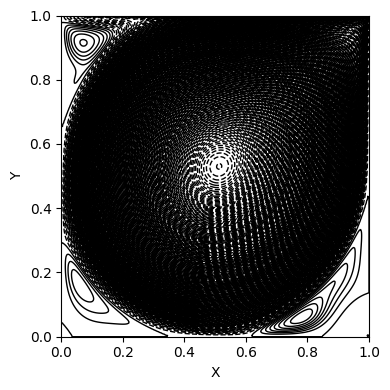

In [ ]:
nx = 257
ny = nx
w, psi, u, v = run_simulation(nx = nx, Re = 10000, alpha = 0.1, Tmax = 4000)

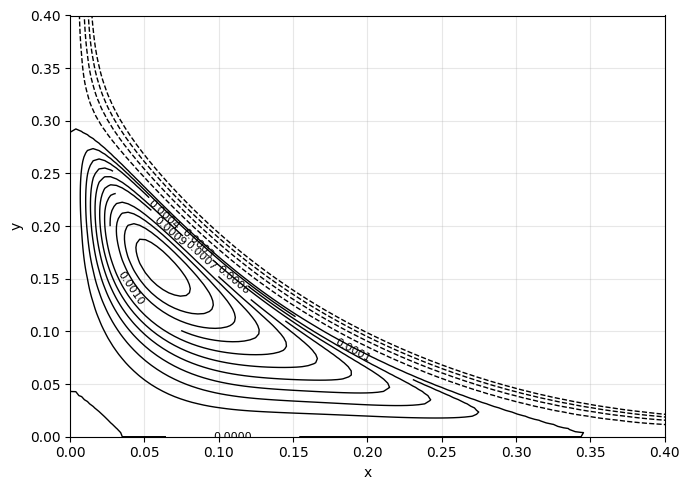

In [ ]:
Lx = 1
Ly = 1
x_np = np.linspace(0, Lx, nx)
y_np = np.linspace(0, Ly, ny)
X,Y = np.meshgrid(x_np, y_np)

# Definir limites para os níveis
range_value = 0.002  # Ajuste conforme necessário
levels_pos = np.linspace(0, range_value, 15)
levels_neg = np.linspace(-range_value, 0, 5)[:-1]
levels_to_plot = np.concatenate([levels_neg, levels_pos])

fig = plt.figure(figsize=(7, 5), dpi=100)

# Plot com contour lines
contour = plt.contour(X, Y, psi.data[0].T,
                      levels=levels_to_plot,
                      colors='k',
                      linewidths=1,
                      alpha=1)

# Adicionar rótulos com os valores nas linhas
plt.clabel(contour, inline=True, fontsize=8, fmt='%.4f')

plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, 0.4)
plt.ylim(0, 0.4)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()